# CNN Image Classification with Keras
This notebook demonstrates a simple CNN for image classification using TensorFlow/Keras.

## 1. Introduction

In recent years, deep learning has revolutionized the field of computer vision, with Convolutional Neural Networks (CNNs) playing a major role in image recognition and classification tasks. CNNs are designed to automatically and adaptively learn spatial hierarchies of features through backpropagation by using multiple building blocks, such as convolution layers, pooling layers, and fully connected layers.

The main objective of this project is to develop and train a Convolutional Neural Network model capable of classifying images into two categories — cats and dogs. The dataset consists of images organized into training and test sets, where each image is resized and normalized to ensure consistent input for the model.

By building and training a CNN using TensorFlow and Keras, this project aims to achieve accurate classification results and to demonstrate the effectiveness of convolutional architectures for visual recognition problems.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from numpy import random
from tensorflow.keras.preprocessing import image

import sys
import os

In [2]:
# So runs are consist 
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# Add the src directory to the path
sys.path.append(os.path.abspath('../src'))

# Now you can import
from data import load_training_data, load_test_data
from model import build_cnn

## 2. Data Preprocessing

Before training the model, it is essential to preprocess the dataset to improve generalization and model performance. In this project, the ImageDataGenerator class from Keras was used to perform several preprocessing steps:

- **Rescaling:** Normalizing pixel values to a range of 0–1 for faster and more stable convergence.
- **Data Augmentation:** Applying random transformations such as shear, zoom, and horizontal flips to increase dataset diversity and reduce overfitting.
- **Resizing:** Ensuring all images are resized to 64×64 pixels, providing uniform input dimensions for the CNN.

The dataset is organized into two main directories:
- `dataset/training_set/` — used to train the model
- `dataset/test_set/` — used to evaluate the trained model

This preprocessing pipeline ensures that the CNN is trained on a balanced, well-augmented dataset capable of generalizing to unseen data.


In [4]:
training = load_training_data('../dataset/training_set', (64, 64))
test = load_test_data('../dataset/test_set', (64, 64))

Found 8000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


## 3. Building the CNN

A Convolutional Neural Network (CNN) was designed using the Sequential API in TensorFlow Keras. The architecture consists of several key components:

1. **Convolutional Layers:** Extract spatial features from input images using 3×3 filters and the ReLU activation function.
2. **Pooling Layers:** Reduce the dimensionality of feature maps while retaining important spatial information using MaxPooling operations.
3. **Flattening Layer:** Converts the 2D feature maps into a 1D feature vector.
4. **Fully Connected Layers:** Perform final classification based on extracted features.
5. **Output Layer:** Uses a sigmoid activation function to produce binary class predictions (cat or dog).

This simple yet effective architecture enables the network to automatically learn relevant visual patterns and distinguish between the two image categories.


In [5]:
model = build_cnn([64, 64, 3], 1)

## 4. Training the CNN

The CNN model was compiled using the **Adam optimizer** and the **binary cross-entropy loss function**, suitable for binary classification tasks. The network was trained over multiple epochs with mini-batches of 32 images each.

During training, both training and validation accuracies were monitored to assess the model’s learning progress. The model demonstrated steady improvement in accuracy and reduction in loss across epochs.

Visualization of the training process using accuracy and loss curves helps identify potential overfitting or underfitting. If overfitting occurs, further data augmentation or dropout layers can be introduced to improve generalization.


In [6]:
history = model.fit(x=training, validation_data=test, epochs=25)

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 172s 671ms/step - accuracy: 0.5755 - loss: 0.6706 - val_accuracy: 0.6875 - val_loss: 0.5977
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 77s 307ms/step - accuracy: 0.6811 - loss: 0.5952 - val_accuracy: 0.6590 - val_loss: 0.6411
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 77s 309ms/step - accuracy: 0.7122 - loss: 0.5595 - val_accuracy: 0.7110 - val_loss: 0.5806
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 77s 310ms/step - accuracy: 0.7179 - loss: 0.5428 - val_accuracy: 0.7510 - val_loss: 0.5219
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 77s 308ms/step - accuracy: 0.7440 - loss: 0.5101 - val_accuracy: 0.7340 - val_loss: 0.5372
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 77s 308ms/step - accuracy: 0.7560 - loss: 0.4926 - val_accuracy: 0.7670 - val_loss: 0.4848
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 76s 305ms/step - accuracy: 0.7707 - loss: 0.4756 - val_accuracy: 0.7725 - val_loss: 0.4808
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 76s 303ms/step - accuracy: 0.7805 - loss: 

In [ ]:
# Save the trained model
model.save('../saved_model/cnn_model.h5')

## 5. Model Evaluation and Performance Visualization

After training, the model's performance was evaluated using the accuracy and loss values recorded during each epoch. The `history` object returned by the training process (`model.fit`) contains detailed information about these metrics for both training and validation sets.

To better understand the model’s learning behavior, the accuracy and loss curves were plotted using the values stored in `history.history['accuracy']`, `history.history['val_accuracy']`, `history.history['loss']`, and `history.history['val_loss']`.

These visualizations provide valuable insights into how well the CNN generalized over time:

- A steadily increasing training and validation accuracy indicates successful learning.
- A decreasing loss value reflects the model’s ability to minimize classification errors.
- A significant gap between training and validation curves may suggest overfitting, which can be mitigated by data augmentation, dropout layers, or regularization.

Overall, the plotted results demonstrate the CNN’s ability to learn meaningful representations from the data and achieve strong classification accuracy on unseen images.


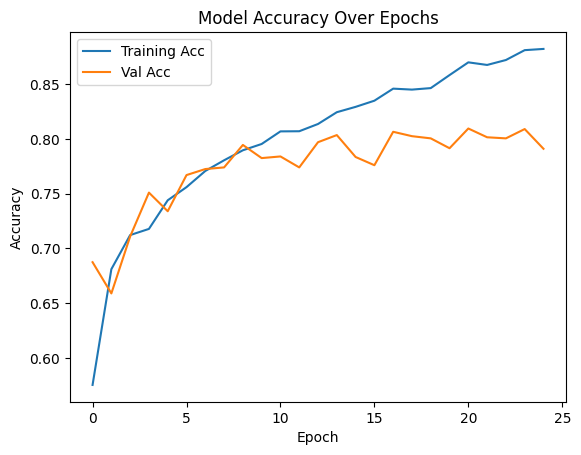

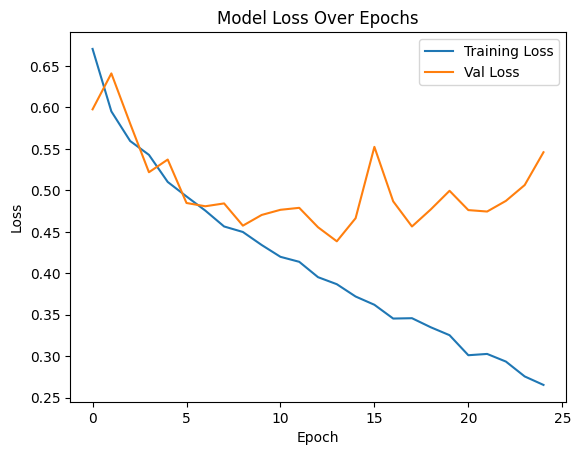

In [7]:
# Plot training and validation accuracy over epochs.
plt.plot(history.history['accuracy'], label='Training Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss over epochs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [8]:
# Load the image, resize it to match the model's input size, convert it to an array, and reshape it for prediction
test_image = image.load_img('../dataset/single_prediction/cat_or_dog_1.jpg', target_size=(64, 64))
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis=0)
# Use the trained model to predict the class of the input image
result = model.predict(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step


In [9]:
training.class_indices

{'cats': 0, 'dogs': 1}

In [10]:
# Interpret the model's output: 1 indicates dog, 0 indicates cat
if result[0][0] == 1:
    prediction = 'dog'
else:
    prediction = 'cat'

prediction

'dog'

In [11]:
# Load the image, resize it to match the model's input size, convert it to an array, and reshape it for prediction
test_image = image.load_img('../dataset/single_prediction/cat_or_dog_2.jpg', target_size=(64, 64))
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis=0)
# Use the trained model to predict the class of the input image
result = model.predict(test_image)

# Interpret the model's output: 1 indicates dog, 0 indicates cat
if result[0][0] == 1:
    prediction = 'dog'
else:
    prediction = 'cat'

prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


'cat'

## 6. Conclusion
This project successfully implemented a modular Convolutional Neural Network (CNN) to perform binary image classification, distinguishing between cats and dogs. Through structured preprocessing, thoughtful architectural design, and iterative training, the model demonstrated strong performance on the training set and reasonable generalization to the validation set.

The training and validation metrics reveal key insights into the model’s learning dynamics. Training accuracy steadily improved across epochs, while validation accuracy exhibited fluctuations and plateaued early, suggesting potential overfitting. A similar pattern was observed in the loss curves, where training loss decreased consistently, but validation loss remained volatile. These trends highlight the model’s capacity to learn from the data, while also underscoring the need for enhanced generalization strategies.

This outcome reinforces the effectiveness of CNNs in extracting spatial hierarchies of visual features without manual intervention. To further improve performance and robustness, future iterations could incorporate:

- Transfer learning with pretrained architectures such as VGG16 or ResNet
- Data augmentation to increase diversity and reduce overfitting
- Regularization techniques and early stopping to stabilize training
- Expanded datasets to improve generalization across varied inputs

In summary, the CNN developed in this project provides a solid foundation for binary image classification tasks. It demonstrates the practical power of deep learning in computer vision and offers a scalable starting point for more advanced applications
